# Notebook 6 — Early Warning Systems (EWS)

This notebook models heat-health warning systems as a **city-level mortality-reduction policy** layered on top of the **current AC baseline** prepared in `NB05`.

The workflow is:
1. Load the daily heat hazard from `NB03`, the year-specific impact functions from `NB04`, and the baseline AC coverage from `NB05`.
2. Recompute daily heat deaths under **current AC**, which is the baseline against which the EWS policy is evaluated.
3. Load the **epidemiology-based daily-deaths threshold** calibrated in `NB05`, and define warning days when modeled daily citywide heat deaths exceed that threshold during the configured warning season.
4. Apply the EWS policy only on warning days, with the city-configured efficacy, ramp-up, AC-EWS overlap, mortality displacement, and residual life-years.
5. Extend the anchor-year results to the common 25-year discounted horizon used later in `NB08`.

For Rome, the config treats EWS as a **marginal enhancement of an existing mature HHWWS**, with a warning season from **May 1 to September 30**. The operative efficacy is therefore the **age-differentiated marginal efficacy** in the YAML, not the counterfactual efficacy used only for sensitivity work.

A key modeling choice is that warning activation is **not based on a fixed temperature threshold**. The trigger is a **daily heat-deaths threshold** exported by `NB05`, so warning days track the modeled epidemiological burden rather than temperature alone.


In [1]:
import os
os.environ["CITY"] = "Rome"   # pick the city here


In [2]:
# Repository bootstrap and city-specific path setup
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Read the city from the environment so each notebook copy stays self-contained
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: Rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
# Load the resolved city config and the file references needed later in the workflow
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# Keep the FUA path in scope for consistency with later city-specific notebooks
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# Quick checks on the resolved inputs
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gvi/gvi_356_cities.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/coefs_GVI_lst.csv


## Setup and libraries

The next cells bootstrap the repository, resolve the city YAML, and load the packages used for hazard, exposure, mortality, and cost calculations. The executable workflow is shared across the three city copies, while the quantitative EWS behaviour is driven by each city's `ews:` config block.


In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import rasterio as rio

from climada.hazard import Hazard
from climada.entity.exposures import Exposures

plt.rcParams.update({"figure.dpi": 130})

## Study years and common CBA settings

`NB06` works on the climate years defined in the city config and on the common discounted horizon defined in the `cba:` block. The anchor-year calculations are performed directly on those modeled years, and later expanded to the 25-year horizon needed for `NB08`.


In [5]:
STUDY_YEARS = cfg.get("climate", {}).get("years", [2020, 2030, 2040, 2050])

# Read the common CBA settings from the YAML
cba_cfg = cfg.get("cba", {})
DISCOUNT_RATE = cba_cfg.get("discount_rate", 0.03)
HORIZON_YEARS = cba_cfg.get("horizon_years", 25)

# Read the EWS block from the YAML; generic defaults below are overwritten city by city
ews_cfg = cfg.get("ews", {})

## EWS configuration

The quantitative behaviour of this notebook is controlled by the `ews:` block in `rome.yml`. The parameters that actually affect results here are the warning season, the deaths-based activation threshold, the efficacy interpretation and values, the ramp-up, the AC-overlap penalty, mortality displacement, residual life-years, and the chosen cost model.

For Rome:
- archetype: enhancement of an existing mature HHWWS
- interpretation: `marginal`
- warning season: `05-01` to `09-30`
- threshold source: deaths threshold exported by `NB05`, calibrated to target about 23 warning days in the 2020 reference year
- threshold recalibration: enabled in the config; the current implementation operationalises it by population-scaling the threshold over time
- efficacy used in the main analysis: age-differentiated marginal efficacy by scenario and age group
- ramp-up: 3 years, starting at 10% of full efficacy
- cost model default: `pavanello`
- setup CAPEX: none

The YAML also stores metadata such as alert tiers, targeting channels, and archetype labels. Those descriptors are exported for documentation, but the mortality calculations below are driven by the quantitative settings listed above.


In [6]:
EWS_CONFIG = {
    # Shared template for the EWS parameter block; city YAML values override the operative settings.
    # Threshold settings: NB06 uses the deaths-based trigger exported by NB05.
    'threshold_method': 'epi_deaths_file',
    'threshold_file': None,
    'threshold_key': 'threshold_deaths_per_day',
    'threshold_unit': 'heat_deaths_per_day',
    'target_activation_days': 23,
    'threshold_ref_year': 2020,
    'threshold_recalib_interval': 5,   # configuration flag; when enabled, the current code population-scales thresholds over time

    'warning_months': [5, 6, 7, 8, 9],

    # Interpretation: marginal enhancement versus counterfactual system establishment
    'interpretation': 'marginal',

    # Counterfactual efficacy: flat scenario-level values used when EWS is modeled as full-system establishment
    'efficacy_counterfactual': {
        'low': 0.20, 'central': 0.35, 'high': 0.50
    },

    # Marginal efficacy: age-specific scenario values used when the policy enhances an existing system.
    'efficacy_marginal': {
        '<15':   {'low': 0.02, 'central': 0.05, 'high': 0.08},
        '15-64': {'low': 0.03, 'central': 0.07, 'high': 0.12},
        '65+':   {'low': 0.08, 'central': 0.15, 'high': 0.25},
    },

    # Ramp-up: time needed for the policy to reach full operational effectiveness
    'ramp_years': 3,
    'ramp_initial_efficacy': 0.10,

    # Cost model: either population-based (Pavanello) or warning-day-based (Chiabai)
    'cost_model': 'pavanello',   # 'pavanello' or 'chiabai'

    'pavanello': {
        'usd_per_capita_per_day': 0.014,
        'eur_usd_rate': 0.92,
        'cost_source': 'Pavanello & Valenti 2024 via Ebi 2004',
    },
    'chiabai': {
        'opex_per_warning_day_basic': 7_800,
        'opex_per_warning_day_enhanced': 14_000,
        'opex_per_warning_day_incremental': 6_200,
        'cost_source': 'Chiabai et al. (Spain/Madrid) Table 4 (projected 2020; base €2013)',
    },

    'capex_setup': 0,
    'opex_annual_fixed': 0,
    'cost_scale_with_population': True,
    'cost_ramp_with_efficacy': True,

    # AC-EWS interaction: higher AC penetration shrinks the pool of deaths that EWS can still prevent.
    'ac_overlap_factor': {'low': 0.3, 'central': 0.5, 'high': 0.7},

    # Mortality displacement: age-specific harvesting fractions used to convert gross to net avoided deaths.
    'displacement': {
        '<15':   {'low': 0.05, 'central': 0.10, 'high': 0.20},
        '15-64': {'low': 0.05, 'central': 0.10, 'high': 0.20},
        '65+':   {'low': 0.10, 'central': 0.25, 'high': 0.40},
    },

    # Residual life years: used to translate net avoided deaths into life-years saved
    'residual_life_years': {
        '<15': 60, '15-64': 25, '65+': 12,
    },
}

# Apply the city-specific YAML overrides so notebook behaviour follows the config
EWS_CONFIG.update(ews_cfg)

import calendar

def resolve_warning_season_cfg(ews_cfg: dict):
    ws = ews_cfg.get("warning_season", {}) or {}
    start_md = ws.get("start_md")
    end_md = ws.get("end_md")
    mode = str(ws.get("mode", "")).strip().lower() or "exact_dates"
    if start_md and end_md:
        return {
            "mode": mode,
            "start_md": str(start_md),
            "end_md": str(end_md),
            "source": "warning_season",
        }

    months = ews_cfg.get("warning_months", [5, 6, 7, 8, 9]) or [5, 6, 7, 8, 9]
    months = sorted({int(m) for m in months if 1 <= int(m) <= 12})
    if not months:
        months = [5, 6, 7, 8, 9]
    start_m = months[0]
    end_m = months[-1]
    end_day = calendar.monthrange(2001, end_m)[1]
    return {
        "mode": "derived_from_months",
        "start_md": f"{start_m:02d}-01",
        "end_md": f"{end_m:02d}-{end_day:02d}",
        "months": months,
        "source": "warning_months_fallback",
    }

WARNING_SEASON_META = resolve_warning_season_cfg(EWS_CONFIG)
SEASON_START_MD = WARNING_SEASON_META["start_md"]
SEASON_END_MD = WARNING_SEASON_META["end_md"]
SEASON_LABEL = f"{SEASON_START_MD} to {SEASON_END_MD}"


# --- Build efficacy structures based on interpretation ---
if EWS_CONFIG['interpretation'] == 'counterfactual':
    # Flat efficacy: dict of {scenario: float}
    EFFICACY_SCENARIOS = EWS_CONFIG['efficacy_counterfactual']
    AGE_DIFFERENTIATED = False
    print("\n  Using COUNTERFACTUAL interpretation (flat efficacy)")
else:
    # Age-differentiated: dict of {age: {low, central, high}}
    eff_marg = EWS_CONFIG['efficacy_marginal']
    AGE_DIFFERENTIATED = True

    # Check if first value is a dict (age-differentiated) or float (flat legacy)
    first_val = next(iter(eff_marg.values()))
    if isinstance(first_val, (int, float)):
        # Legacy flat format: {'low': 0.05, 'central': 0.10, 'high': 0.15}
        EFFICACY_SCENARIOS = eff_marg
        AGE_DIFFERENTIATED = False
        print("\n  Using MARGINAL interpretation (flat efficacy, legacy format)")
    else:
        # Age-differentiated: {'<15': {'low':..., 'central':..., 'high':...}, ...}
        EFFICACY_SCENARIOS_BY_AGE = eff_marg
        # Build scenario list from first age group's keys
        SCENARIO_NAMES = list(next(iter(eff_marg.values())).keys())
        print(f"\n  Using MARGINAL interpretation (age-differentiated efficacy)")
        print(f"    Scenarios: {SCENARIO_NAMES}")
        for ag, vals in EFFICACY_SCENARIOS_BY_AGE.items():
            print(f"    {ag}: {vals}")

# Displacement parameters
DISPLACEMENT_BY_AGE = EWS_CONFIG.get('displacement', {})
RESIDUAL_LIFE_YEARS = EWS_CONFIG.get('residual_life_years', {})
AC_OVERLAP = EWS_CONFIG.get('ac_overlap_factor', {})

print("\n" + "=" * 70)
print("Notebook 6: Early Warning System (HHWWS) Policy — IMPROVED")
print("=" * 70)
print(f"\n  Interpretation:   {EWS_CONFIG['interpretation'].upper()}")
print(f"  Age-differentiated: {AGE_DIFFERENTIATED}")
print(f"  Cost model:       {EWS_CONFIG.get('cost_model', 'chiabai')}")
print(f"  AC-EWS overlap:   {AC_OVERLAP}")
print(f"  Displacement:     {'ON' if DISPLACEMENT_BY_AGE else 'OFF'}")
print(f"  Threshold recalib: every {EWS_CONFIG.get('threshold_recalib_interval', 'N/A')} years")
print(f"  Warning season:   {SEASON_LABEL} ({WARNING_SEASON_META.get('source')})")


  Using MARGINAL interpretation (age-differentiated efficacy)
    Scenarios: ['low', 'central', 'high']
    <15: {'low': 0.02, 'central': 0.05, 'high': 0.08}
    15-64: {'low': 0.03, 'central': 0.07, 'high': 0.12}
    65+: {'low': 0.08, 'central': 0.15, 'high': 0.25}

Notebook 6: Early Warning System (HHWWS) Policy — IMPROVED

  Interpretation:   MARGINAL
  Age-differentiated: True
  Cost model:       pavanello
  AC-EWS overlap:   {'low': 0.3, 'central': 0.5, 'high': 0.7}
  Displacement:     ON
  Threshold recalib: every 5 years
  Warning season:   05-01 to 09-30 (warning_season)


In [7]:
# The city-specific EWS configuration is fully assembled in the cell above.


## 1. Load upstream inputs

`NB06` does not create new hazard or exposure layers. Instead, it assembles the upstream outputs required to evaluate EWS on the same modelling basis as the rest of the framework:
- the reference grid and city mask from `NB02`
- the daily T2M hazard and event calendar from `NB03`
- the age-structured population exposures from `NB03`
- the year-specific impact functions from `NB04`
- the baseline AC coverage from `NB05`

This keeps the EWS analysis internally consistent with the mortality baseline already used for AC and with the downstream CBA in `NB08`.


### 1.1 Reference grid and masks

Everything in `NB06` stays on the common reference grid built upstream. This guarantees that hazard, population, AC coverage, and later policy comparisons all use the same spatial support.


In [8]:
import json, numpy as np, geopandas as gpd, rasterio as rio 

print("\n1.1 Loading reference grid...")

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

print(f"  Reference grid: {HGT}×{WDT} | CRS: {ref_meta['crs']}")
print(f"  CITY_MASK pixels: {CITY_MASK.sum():,}")


1.1 Loading reference grid...
  Reference grid: 301×301 | CRS: EPSG:3035
  CITY_MASK pixels: 77,929


### 1.2 Daily hazard with event dates

The heat hazard itself comes from `NB03`. Here we reattach the daily dates and event frequencies so warning days can be defined on the correct calendar.


In [9]:
print("\n1.2 Loading hazard data...")

def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)
    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."
    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)
    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)
H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = np.sort(dates_h.dt.year.unique()).astype(int).tolist()
print(f"  Loaded hazard: {H.intensity.shape[0]} events × {H.intensity.shape[1]} cells")
print(f"  Years: {YEARS_H}")


1.2 Loading hazard data...
  Loaded hazard: 1462 events × 90601 cells
  Years: [2020, 2030, 2040, 2050]


### 1.3 Age-specific exposures by year

The exposure manifest links each climate year to the population arrays prepared in `NB03`. The notebook follows the configured scenario choice, with safe fallbacks to the available manifest entries when needed.


In [10]:
print("\n1.3 Loading exposure data...")

expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    expo_manifest = json.load(f)

# Load the age-specific exposure arrays prepared upstream in NB03
direct_wp_all = expo_manifest.get("direct_worldpop", {})
_baseline_key = sorted(direct_wp_all.keys())[0]  # first year (typically "2020")
_bl = direct_wp_all[_baseline_key]
agez = np.load(_bl["age_npz"])
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(_bl["pop_npz"])["pop"]
print(f"  Baseline exposure loaded from manifest (year {_baseline_key})")

# Pick the exposure scenario from config, with fallbacks to the available manifest entries
scen_dict = expo_manifest.get("scenarios", {})
direct_wp = expo_manifest.get("direct_worldpop", {})  # WorldPop years (no SSP)

scenario_cfg = (cfg or {}).get("scenario", {}) or {}
SCEN_CODE = scenario_cfg.get("code")
if not SCEN_CODE:
    SCEN_CODE = cfg.get("exp_scenario")
if (not SCEN_CODE or SCEN_CODE not in scen_dict):
    ac_cfg_tmp = cfg.get("ac", {})
    ssp = ac_cfg_tmp.get("ssp", None)
    if ssp is not None:
        for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
            if cand in scen_dict:
                SCEN_CODE = cand
                break
if not SCEN_CODE or SCEN_CODE not in scen_dict:
    SCEN_CODE = sorted(scen_dict.keys())[0]
print(f"  Using exposure scenario: {SCEN_CODE}")

baseline_rec = expo_manifest.get("baseline", {})
BASELINE_YEAR = baseline_rec.get("year", 2020)

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

def _load_age_pop(npz_age_path, npz_pop_path):
    """Load age + pop arrays from npz paths."""
    ages_npz = np.load(npz_age_path)
    pop_npz_f = np.load(npz_pop_path)
    age_dict = {
        "<15":   ages_npz["lt15"].astype("float32"),
        "15-64": ages_npz["a15_64"].astype("float32"),
        "65+":   ages_npz["g65"].astype("float32"),
    }
    pop_arr = pop_npz_f["pop"].astype("float32")
    return age_dict, pop_arr

for y in YEARS_H:
    sy = str(y)

    if y == BASELINE_YEAR:
        # Baseline year: use pre-loaded arrays or baseline record
        if "age_npz" in baseline_rec and "pop_npz" in baseline_rec:
            ad, pa = _load_age_pop(baseline_rec["age_npz"], baseline_rec["pop_npz"])
            age_on_ref_by_year[int(y)] = ad
            pop_on_ref_by_year[int(y)] = pa
            print(f"    {y}: Loaded from baseline record")
        else:
            age_on_ref_by_year[int(y)] = {k: v.astype("float32") for k, v in age_on_ref.items()}
            pop_on_ref_by_year[int(y)] = pop_on_ref.astype("float32")
            print(f"    {y}: Using pre-loaded baseline arrays")
        continue

    # Try scenario data first (SSP-differentiated: typically 2040, 2050)
    scen_rec = scen_dict.get(SCEN_CODE, {})
    rec_y = scen_rec.get(sy)

    if rec_y is not None:
        ad, pa = _load_age_pop(rec_y["age_npz"], rec_y["pop_npz"])
        age_on_ref_by_year[int(y)] = ad
        pop_on_ref_by_year[int(y)] = pa
        print(f"    {y}: Loaded from scenario {SCEN_CODE}")
        continue

    # Fallback: direct_worldpop (no SSP; typically 2020, 2030)
    wp_rec = direct_wp.get(sy)
    if wp_rec is not None:
        ad, pa = _load_age_pop(wp_rec["age_npz"], wp_rec["pop_npz"])
        age_on_ref_by_year[int(y)] = ad
        pop_on_ref_by_year[int(y)] = pa
        print(f"    {y}: Loaded from direct_worldpop (no SSP)")
        continue

    raise KeyError(
        f"No exposure data for year {y}: not in scenario {SCEN_CODE} "
        f"(has {list(scen_rec.keys())}), not in direct_worldpop "
        f"(has {list(direct_wp.keys())}), and not baseline year ({BASELINE_YEAR})"
    )


1.3 Loading exposure data...
  Baseline exposure loaded from manifest (year 2020)
  Using exposure scenario: SSP2
    2020: Using pre-loaded baseline arrays
    2030: Loaded from direct_worldpop (no SSP)
    2040: Loaded from scenario SSP2
    2050: Loaded from scenario SSP2


### 1.4 Year-specific impact functions from `NB04`

`NB04` already calibrated and scaled the impact functions by age and year. `NB06` loads those curves directly; it does not recalibrate them here.


In [11]:
print("\n1.4 Loading impact function curves...")

def load_if_curves_by_year(INT, OUT, slug):
    """
    Load year-specific IF curves from NB4 output.
    NB4 saves to: INT / f"if_curves_by_year_{slug}.json"
    
    JSON structure:
    {
        "reference_year": 2020,
        "years": [2020, 2030, ...],
        "ifs_by_year": {
            "2020": {"<15": {...}, "15-64": {...}, "65+": {...}},
            ...
        }
    }
    """
    candidates = [
        INT / f"if_curves_by_year_{slug}.json",    # NB4 primary
        INT / f"if_curves_frozen_{slug}.json",      # NB4 legacy
        INT / "if_curves_by_year.json",             # generic
        OUT / f"if_curves_by_year_{slug}.json",
    ]
    p = None
    for c in candidates:
        if c.exists():
            p = c
            print(f"    Found IF curves: {c}")
            break
    if p is None:
        raise FileNotFoundError(
            f"Missing IF bundle JSON for {slug}.\n"
            f"Expected one of: {[str(c) for c in candidates]}\n"
            f"Please run NB4 first to generate IF curves."
        )
    
    with open(p, "r") as f:
        obj = json.load(f)
    
    # NB6 pattern: extract ifs_by_year from the JSON structure
    raw = obj.get("ifs_by_year", {})
    if not raw:
        # Fallback: maybe the JSON is directly year->age->curves
        # Check if keys are year-like integers
        if all(k.isdigit() for k in obj.keys() if k not in ["reference_year", "years", "scaling_source"]):
            raw = {k: v for k, v in obj.items() if k.isdigit()}
        else:
            raise ValueError(f"{p.name} has no 'ifs_by_year' key and doesn't appear to be a direct year->curves mapping.")
    
    # Build IFS_BY_YEAR dict with int keys
    IFS_BY_YEAR = {}
    for y_key, d in raw.items():
        y = int(y_key)
        IFS_BY_YEAR[y] = {}
        for age_lbl, curves in d.items():
            IFS_BY_YEAR[y][age_lbl] = {
                "intensity": np.asarray(curves["intensity"], float),
                "mdd": np.asarray(curves["mdd"], float),
            }
    
    # Build getter function (matching NB6 pattern)
    def get_age_ifs_for_year(year: int):
        """Get age-specific impact functions for a given year."""
        year = int(year)
        if year not in IFS_BY_YEAR:
            raise KeyError(f"No SCALED IFs for year {year}. Available: {sorted(IFS_BY_YEAR.keys())}")
        return IFS_BY_YEAR[year]
    
    # Extract metadata
    meta = {
        "reference_year": obj.get("reference_year", None),
        "years": obj.get("years", sorted(IFS_BY_YEAR.keys())),
    }
    
    age_labels = list(next(iter(IFS_BY_YEAR.values())).keys())
    return get_age_ifs_for_year, age_labels, meta

get_age_ifs_for_year, IF_AGE_LABELS, IF_META = load_if_curves_by_year(INT, OUT, SLUG)
print(f"  Loaded IF curves, age groups: {IF_AGE_LABELS}")
print(f"  Years available: {IF_META['years']}")


1.4 Loading impact function curves...
    Found IF curves: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_by_year_rome.json
  Loaded IF curves, age groups: ['<15', '15-64', '65+']
  Years available: [2020, 2030, 2040, 2050]


### 1.5 Baseline AC coverage from `NB05`

`NB05` provides the spatial baseline AC coverage that defines the mortality baseline in this notebook. The same cell also reads the age-specific AC efficacy used to attenuate deaths before the EWS policy is layered on top.


In [12]:
print("\n1.5 Loading AC coverage (baseline)...")

def load_ac_coverage_current(INT, OUT, slug):
    """
    Load AC baseline coverage from NB5 output.
    The refreshed city-specific bundle is written to OUT and should be preferred
    over legacy interim files so downstream notebooks inherit the corrected
    baseline AC state.
    """
    candidates = [
        OUT / f"ac_coverage_maps_{slug}.npz",   # refreshed NB5 output
        INT / f"ac_coverage_maps_{slug}.npz",   # legacy city-specific fallback
        INT / "ac_coverage_maps.npz",           # legacy generic fallback
    ]
    p = None
    for c in candidates:
        if c.exists():
            p = c
            print(f"    Found AC file: {c}")
            break
    if p is None:
        raise FileNotFoundError(
            f"Missing AC NPZ output from NB5 for {slug}.\n"
            f"Expected one of: {[str(c) for c in candidates]}\n"
            f"Please run NB5 first to generate AC coverage maps."
        )
    
    z = np.load(p, allow_pickle=True)
    print(f"    NPZ keys: {list(z.keys())}")
    
    # Accept both "YEARS_AC" (legacy) and "years" (current NB5)
    years_key = "YEARS_AC" if "YEARS_AC" in z else "years"
    if "coverage_base_3d" in z and years_key in z:
        years = [int(x) for x in z[years_key]]
        cov3d = z["coverage_base_3d"]
        coverage_by_year = {y: cov3d[i].astype("float32") for i, y in enumerate(years)}
    else:
        raise KeyError(
            f"AC NPZ missing expected keys. Found: {list(z.keys())}\n"
            f"Need: coverage_base_3d + (YEARS_AC or years)"
        )
    
    return coverage_by_year

coverage_base_by_year = load_ac_coverage_current(INT, OUT, SLUG)
YEARS_AC = sorted(coverage_base_by_year.keys())
print(f"  Loaded AC baseline coverage for years: {YEARS_AC}")

# Baseline AC efficacy comes from the city YAML and matches the NB5 setup
eff_cfg = cfg.get("efficacy", {})
EFF_BY_AGE = {k: float(v) for k, v in eff_cfg.items() if k != "default"}
EFF_DEFAULT = float(eff_cfg.get("default", 0.30))
print(f"  AC efficacy by age: {EFF_BY_AGE}, default: {EFF_DEFAULT}")


1.5 Loading AC coverage (baseline)...
    Found AC file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/ac_coverage_maps_rome.npz
    NPZ keys: ['years', 'coverage_base_3d', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P', 'coverage_policy_3d', 'coverage_uniform_3d']
  Loaded AC baseline coverage for years: [2020, 2030, 2040, 2050]
  AC efficacy by age: {'<15': 0.2, '15-64': 0.3, '65+': 0.4}, default: 0.3


## 2. Reconstruct daily baseline deaths under current AC

The EWS policy is not compared against a no-adaptation world. Its baseline is the **current-AC baseline** already embedded in the framework: the year-specific impact functions from `NB04` are applied to the daily hazard and then attenuated by the spatial baseline AC coverage from `NB05`.

This is crucial. The EWS policy only acts on the **residual mortality burden that remains after current AC is already in place**. That same baseline is then used to determine both the warning threshold exceedances and the avoided deaths attributable to EWS.


In [13]:
print("\n" + "=" * 70)
print("2. COMPUTING BASELINE DEATHS (under current AC)")
print("=" * 70)

def _row_to_1d(mat, i):
    """Get i-th row as 1D float array; supports scipy sparse."""
    row = mat[i]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row, float).ravel()

def compute_citymean_daily(H, city_mask_1d):
    """Compute city-mean temperature for each day, using only city pixels."""
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    cm = []
    for i in range(H.intensity.shape[0]):
        I = _row_to_1d(H.intensity, i)
        # Use city mask to compute mean over city pixels only
        m = city_mask_1d & np.isfinite(I)
        cm.append(float(np.nanmean(I[m])) if np.any(m) else np.nan)
    return dates, np.asarray(cm, float)

def daily_deaths_current_ac(H, city_mask_1d, age_by_year, coverage_by_year, 
                            get_age_ifs_for_year,
                            eff_by_age: dict, eff_default: float = 0.30):
    """
    Compute daily deaths under current AC coverage.
    This matches NB5's death computation: np.nansum(pop * mdd * mult)
    """
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    years = dates.dt.year.astype(int).to_numpy()
    
    # Infer age labels
    age_labels = list(next(iter(age_by_year.values())).keys())
    
    rows = []
    for i, dt in enumerate(dates):
        y = int(years[i])
        
        I = _row_to_1d(H.intensity, i)
        cov = np.asarray(coverage_by_year[y], float).ravel().copy()
        
        age_ifs = get_age_ifs_for_year(y)
        deaths_age = {}
        
        pop_total = np.zeros_like(cov, dtype=float)
        for a in age_labels:
            pop_total += np.nan_to_num(np.asarray(age_by_year[y][a], float).ravel(), nan=0.0)
        
        # Fill any AC coverage gaps inside the city with the population-weighted city mean.
        m_cov = city_mask_1d & np.isfinite(pop_total) & (pop_total > 0)
        if np.any(m_cov) and np.isnan(cov[m_cov]).any():
            w = pop_total[m_cov].astype(float)
            x = np.nan_to_num(cov[m_cov], nan=0.0).astype(float)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov = np.where(m_cov & np.isnan(cov), mean_cov, cov)
        cov = np.where(city_mask_1d & np.isfinite(cov), cov, 0.0)
        
        # Mask: city pixels with valid temperature
        m = city_mask_1d & np.isfinite(I)
        
        for a in age_labels:
            pop = np.nan_to_num(np.asarray(age_by_year[y][a], float).ravel(), nan=0.0)
            
            f = age_ifs[a]
            mdd = np.interp(I, f["intensity"], f["mdd"], left=f["mdd"][0], right=f["mdd"][-1])
            
            eff_a = float(eff_by_age.get(a, eff_default))
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
            
            # Death computation matches NB5: np.nansum(pop * mdd * mult)
            deaths = float(np.nansum(pop[m] * mdd[m] * mult[m]))
            deaths_age[a] = deaths
        
        rows.append({
            "date": dt,
            "year": int(dt.year),
            "month": int(dt.month),
            **{f"deaths_{a}": v for a, v in deaths_age.items()},
            "deaths_overall": float(sum(deaths_age.values()))
        })
    
    return pd.DataFrame(rows)

# Rebuild daily heat deaths under current AC so EWS is evaluated on the residual baseline
print("\n2.1 Computing daily deaths under current AC...")

# Flatten city mask for vectorized operations
CITY_MASK_1D = CITY_MASK.ravel()

daily_base = daily_deaths_current_ac(
    H=H,
    city_mask_1d=CITY_MASK_1D,
    age_by_year=age_on_ref_by_year,
    coverage_by_year=coverage_base_by_year,
    get_age_ifs_for_year=get_age_ifs_for_year,
    eff_by_age=EFF_BY_AGE,
    eff_default=EFF_DEFAULT,
)

# Attach city-mean temperature for diagnostics and plotting
print("2.2 Attaching city-mean temperature...")
dates_h, citymean = compute_citymean_daily(H, CITY_MASK_1D)
daily_base = daily_base.merge(
    pd.DataFrame({"date": dates_h, "citymean_degC": citymean}), 
    on="date", how="left"
)

# Aggregate to annual
annual_base = daily_base.groupby("year", as_index=False).sum(numeric_only=True)
print(f"\n  Annual baseline deaths (under current AC):")
for _, r in annual_base.iterrows():
    print(f"    {int(r['year'])}: {r['deaths_overall']:.1f} deaths")


2. COMPUTING BASELINE DEATHS (under current AC)

2.1 Computing daily deaths under current AC...
2.2 Attaching city-mean temperature...

  Annual baseline deaths (under current AC):
    2020: 387.7 deaths
    2030: 463.1 deaths
    2040: 493.4 deaths
    2050: 569.3 deaths


## 3. Define warning days from modeled heat deaths

Warning activation is epidemiological rather than meteorological. The notebook loads the deaths-per-day threshold exported by `NB05` and flags warning days when modeled citywide heat deaths exceed that threshold during the configured warning season (`05-01` to `09-30`).

The threshold is calibrated in `NB05` to target about 23 warning days in the 2020 reference year. The YAML also carries a recalibration setting, and the current code operationalises that choice by population-scaling the threshold over time once recalibration is enabled.


In [14]:
print("\n" + "=" * 70)
print("3. COMPUTING WARNING DAYS AND DEATHS ON WARNING DAYS")
print("=" * 70)

from pathlib import Path
import json

def _load_epi_threshold(INT: Path, slug: str, ews_cfg: dict):
    """Load the epidemiology-based EWS activation threshold from NB5 JSON."""
    candidates = []
    if ews_cfg.get("threshold_file") is not None:
        candidates.append(Path(ews_cfg["threshold_file"]))
    candidates += [
        INT / f"ews_threshold_deaths_{slug}_climate_only.json",
        INT / f"ews_threshold_deaths_{slug}.json",
    ]
    key = str(ews_cfg.get("threshold_key", "threshold_deaths_per_day"))
    for p in candidates:
        try:
            if p is None: continue
            p = Path(p)
            if not p.exists(): continue
            j = json.load(open(p, "r"))
            if key not in j:
                raise KeyError(f"Missing key '{key}' in {p}. Keys: {list(j.keys())}")
            meta = {
                "method": "epi_deaths_file", "file": str(p), "key": key,
                "unit": ews_cfg.get("threshold_unit", "heat_deaths_per_day"),
                "baseline_year": j.get("baseline_year", j.get("baseline_year_for_calib")),
                "target_activation_days": j.get("target_activation_days"),
            }
            return float(j[key]), meta
        except Exception as e:
            raise RuntimeError(f"Failed reading threshold from {p}: {e}") from e
    raise FileNotFoundError(
        "Could not find NB5 EWS threshold JSON. Run NB5 first.\n"
        f"Tried: {candidates}"
    )

def pick_threshold(daily_df, ews_cfg, INT, slug):
    method = ews_cfg.get("threshold_method", "epi_deaths_file")
    if method == "epi_deaths_file":
        return _load_epi_threshold(INT, slug, ews_cfg)
    raise ValueError(f"Unknown threshold_method: {method}")

# 3.1 Load baseline threshold 
thr_base, thr_meta = pick_threshold(daily_base, EWS_CONFIG, INT, SLUG)
print(f"\n3.1 Baseline threshold: {thr_base:.4f} deaths/day")
print(f"    Source: {thr_meta.get('file','(n/a)')}")

# 3.2 Threshold recalibration 
# The current implementation scales the threshold with city population change whenever recalibration is enabled
recalib_interval = int(EWS_CONFIG.get('threshold_recalib_interval', 0))
if recalib_interval > 0:
    # Scale threshold proportionally to city population change
    ref_year = int(EWS_CONFIG.get('threshold_ref_year', YEARS_H[0]))
    anchors = sorted(pop_on_ref_by_year.keys())
    pop_totals = {y: float(np.nansum(pop_on_ref_by_year[y])) for y in anchors}
    pop_ref = pop_totals.get(ref_year, pop_totals[anchors[0]])

    threshold_by_year = {}
    for y in YEARS_H:
        pop_y = float(np.interp(y, list(pop_totals.keys()), list(pop_totals.values())))
        threshold_by_year[y] = thr_base * (pop_y / pop_ref) if pop_ref > 0 else thr_base

    print(f"\n3.2 Threshold recalibration (every {recalib_interval}y, pop-scaled):")
    for y, t in threshold_by_year.items():
        print(f"    {y}: {t:.4f} deaths/day (pop ratio: {pop_totals.get(y, 0)/pop_ref:.3f})")
else:
    threshold_by_year = {y: thr_base for y in YEARS_H}
    print(f"\n3.2 Threshold recalibration: OFF (fixed at {thr_base:.4f})")

# 3.3 Identify warning days (year-specific threshold)
def season_mask_by_md(dates_dt, start_md: str, end_md: str):
    dates_dt = pd.to_datetime(dates_dt)
    if isinstance(dates_dt, pd.Series):
        y = dates_dt.dt.year.astype(str)
    else:
        y = pd.Index(dates_dt).year.astype(str)
    start = pd.to_datetime(y + "-" + start_md)
    end = pd.to_datetime(y + "-" + end_md)
    return np.asarray((dates_dt >= start) & (dates_dt <= end), dtype=bool)

if "date" in daily_base.columns:
    season_dates = pd.to_datetime(daily_base["date"])
elif "time" in daily_base.columns:
    season_dates = pd.to_datetime(daily_base["time"])
else:
    season_dates = pd.to_datetime(daily_base.index)

season_mask = season_mask_by_md(season_dates, SEASON_START_MD, SEASON_END_MD)
age_labels = list(next(iter(age_on_ref_by_year.values())).keys())

daily_base["is_warning_day"] = False
for y in YEARS_H:
    thr_y = threshold_by_year[y]
    mask_y = (daily_base["year"] == y) & season_mask & (daily_base["deaths_overall"] >= thr_y)
    daily_base.loc[mask_y, "is_warning_day"] = True

warning_day_counts = (
    daily_base[daily_base["is_warning_day"]]
    .groupby("year").size()
    .reset_index(name="n_warning_days")
)
print(f"\n3.3 Warning days:")
for _, r in warning_day_counts.iterrows():
    print(f"    {int(r['year'])}: {int(r['n_warning_days'])} days")

# 3.4 Deaths on warning days — overall AND by age group 
warning_deaths_overall = (
    daily_base[daily_base["is_warning_day"]]
    .groupby("year")["deaths_overall"].sum()
    .reset_index(name="deaths_on_warning_days")
)

# By age group (needed for age-differentiated efficacy + displacement)
deaths_cols = [c for c in daily_base.columns if c.startswith("deaths_") and c != "deaths_overall"]
warning_deaths_by_age = (
    daily_base[daily_base["is_warning_day"]]
    .groupby("year")[deaths_cols].sum()
    .reset_index()
)

annual_base = annual_base.merge(warning_deaths_overall, on="year", how="left")
annual_base["deaths_on_warning_days"] = annual_base["deaths_on_warning_days"].fillna(0.0)
annual_base["frac_deaths_on_warning_days"] = (
    annual_base["deaths_on_warning_days"] / annual_base["deaths_overall"]
).replace([np.inf, -np.inf], np.nan)

# Merge age-specific warning-day deaths
annual_base = annual_base.merge(warning_deaths_by_age, on="year", how="left", suffixes=("", "_warn"))
# Check whether warning-day columns already carry the expected suffix
for c in deaths_cols:
    col_warn = f"{c}_warn"
    if col_warn not in annual_base.columns:
        # column came from original merge without suffix
        pass

print(f"\n3.4 Deaths on warning days:")
for _, r in annual_base.iterrows():
    frac = r["frac_deaths_on_warning_days"]
    print(f"    {int(r['year'])}: {r['deaths_on_warning_days']:.1f} deaths ({frac*100:.1f}% of annual)")
    for c in deaths_cols:
        age_lbl = c.replace("deaths_", "")
        val = r.get(f"{c}_warn", r.get(c, 0))
        print(f"        {age_lbl}: {val:.1f}")

annual_base = annual_base.merge(warning_day_counts, on="year", how="left")
annual_base["n_warning_days"] = annual_base["n_warning_days"].fillna(0).astype(int)


3. COMPUTING WARNING DAYS AND DEATHS ON WARNING DAYS

3.1 Baseline threshold: 5.3723 deaths/day
    Source: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ews_threshold_deaths_rome_climate_only.json

3.2 Threshold recalibration (every 5y, pop-scaled):
    2020: 5.3723 deaths/day (pop ratio: 1.000)
    2030: 5.1956 deaths/day (pop ratio: 0.967)
    2040: 5.0739 deaths/day (pop ratio: 0.944)
    2050: 4.9748 deaths/day (pop ratio: 0.926)

3.3 Warning days:
    2020: 23 days
    2030: 46 days
    2040: 56 days
    2050: 61 days

3.4 Deaths on warning days:
    2020: 158.0 deaths (40.8% of annual)
        <15: 1.1
        15-64: 15.9
        65+: 141.0
    2030: 315.7 deaths (68.2% of annual)
        <15: 1.1
        15-64: 24.4
        65+: 290.1
    2040: 396.6 deaths (80.4% of annual)
        <15: 0.8
        15-64: 18.2
        65+: 377.6
    2050: 475.7 deaths (83.6% of annual)
        <15: 0.5
        15-64: 12.5
        65+: 462.8


## 4. Apply the EWS policy on warning days

The baseline remains the **current-AC mortality baseline** reconstructed above. The EWS policy only affects the subset of deaths that occur on warning days; it does not alter the hazard itself.

For Rome, the policy is interpreted as a **marginal improvement** to an already-existing system. The notebook therefore uses the age-specific marginal efficacy curves from the YAML, by scenario and age group, and applies them only to warning-day deaths. The sequence is:
1. start from warning-day deaths under current AC
2. scale efficacy during the ramp-up years
3. attenuate efficacy further using the AC-overlap factor, because higher AC penetration means a smaller residual pool of deaths that EWS can still prevent
4. apply age-specific mortality displacement to move from gross to net avoided deaths
5. convert net avoided deaths to life-years saved using the configured residual life expectancy

This section produces the anchor-year EWS benefits that are later extended to a common 25-year CBA horizon.


In [15]:
print("\n" + "=" * 70)
print("4. EWS BASELINE vs POLICY (age-differentiated, with displacement)")
print("=" * 70)

# Helper: ramp factor 
def ews_ramp_factor(year, start_year, ramp_years=3, initial_frac=0.10):
    ys = int(year) - int(start_year)
    if ys < 0: return 0.0
    return float(initial_frac) if ys < int(ramp_years) else 1.0

EWS_START_YEAR = int(annual_base["year"].min())

# Helper: get AC coverage for a year (city-mean) 
def get_city_mean_ac_coverage(year):
    """Get mean AC coverage across city pixels for a given year."""
    cov = coverage_base_by_year.get(year, coverage_base_by_year.get(min(coverage_base_by_year.keys())))
    return float(np.nanmean(cov))

# Infer the age labels from the warning-day death columns
deaths_cols = [c for c in daily_base.columns if c.startswith("deaths_") and c != "deaths_overall"]
age_labels = [c.replace("deaths_", "") for c in deaths_cols]

# Build the annual policy results under the configured efficacy interpretation
rows = []

if AGE_DIFFERENTIATED:
    # Marginal interpretation: age-specific efficacy by scenario
    for scen in SCENARIO_NAMES:  # e.g. ['low', 'central', 'high']
        for _, r in annual_base.iterrows():
            y = int(r["year"])
            total_baseline = float(r["deaths_overall"])
            warn_deaths_total = float(r["deaths_on_warning_days"])

            ramp = ews_ramp_factor(y, EWS_START_YEAR,
                                   int(EWS_CONFIG["ramp_years"]),
                                   float(EWS_CONFIG["ramp_initial_efficacy"]))

            # AC-EWS interaction: reduce EWS efficacy as AC coverage increases
            ac_cov = get_city_mean_ac_coverage(y)
            overlap = float(AC_OVERLAP.get(scen, AC_OVERLAP.get('central', 0.5)))
            ac_penalty = 1.0 - ac_cov * overlap  # e.g. 30% AC × 0.5 overlap = 15% penalty

            gross_avoided_by_age = {}
            net_avoided_by_age = {}
            lys_by_age = {}

            for age_lbl in age_labels:
                # Age-specific efficacy
                age_eff_dict = EFFICACY_SCENARIOS_BY_AGE.get(age_lbl, {})
                eff_full = float(age_eff_dict.get(scen, 0.0))
                eff_effective = eff_full * ramp * ac_penalty

                # Deaths on warning days for this age group
                warn_col = f"deaths_{age_lbl}_warn"
                if warn_col in r.index:
                    warn_deaths_age = float(r[warn_col])
                else:
                    warn_deaths_age = float(r.get(f"deaths_{age_lbl}", 0.0))

                gross_avoided = warn_deaths_age * eff_effective
                gross_avoided_by_age[age_lbl] = gross_avoided

                # Displacement: fraction of avoided deaths that are harvested
                disp_dict = DISPLACEMENT_BY_AGE.get(age_lbl, {})
                disp_frac = float(disp_dict.get(scen, disp_dict.get('central', 0.0)))
                net_avoided = gross_avoided * (1.0 - disp_frac)
                net_avoided_by_age[age_lbl] = net_avoided

                # Life-years saved
                rle = float(RESIDUAL_LIFE_YEARS.get(age_lbl, 10))
                lys_by_age[age_lbl] = net_avoided * rle

            gross_total = sum(gross_avoided_by_age.values())
            net_total = sum(net_avoided_by_age.values())
            lys_total = sum(lys_by_age.values())

            rows.append({
                "year": y,
                "scenario": scen,
                "baseline_deaths_total": total_baseline,
                "baseline_deaths_on_warning_days": warn_deaths_total,
                "baseline_warning_days": int(r.get("n_warning_days", 0)),
                "ramp_factor": ramp,
                "ac_coverage": ac_cov,
                "ac_penalty": ac_penalty,
                "gross_avoided_deaths": gross_total,
                "net_avoided_deaths": net_total,
                "life_years_saved": lys_total,
                "policy_deaths_total": total_baseline - net_total,
                **{f"gross_avoided_{a}": gross_avoided_by_age[a] for a in age_labels},
                **{f"net_avoided_{a}": net_avoided_by_age[a] for a in age_labels},
                **{f"lys_{a}": lys_by_age[a] for a in age_labels},
            })
else:
    # Counterfactual interpretation: flat efficacy by scenario, with the same ramp, overlap, and displacement logic
    for scen, eff_full in EFFICACY_SCENARIOS.items():
        for _, r in annual_base.iterrows():
            y = int(r["year"])
            total = float(r["deaths_overall"])
            warn_deaths_total = float(r["deaths_on_warning_days"])

            ramp = ews_ramp_factor(y, EWS_START_YEAR,
                                   int(EWS_CONFIG["ramp_years"]),
                                   float(EWS_CONFIG["ramp_initial_efficacy"]))

            ac_cov = get_city_mean_ac_coverage(y)
            overlap = float(AC_OVERLAP.get(scen, AC_OVERLAP.get('central', 0.5)))
            ac_penalty = 1.0 - ac_cov * overlap

            gross_avoided_by_age = {}
            net_avoided_by_age = {}
            lys_by_age = {}

            for age_lbl in age_labels:
                warn_col = f"deaths_{age_lbl}_warn"
                if warn_col in r.index:
                    warn_deaths_age = float(r[warn_col])
                else:
                    warn_deaths_age = float(r.get(f"deaths_{age_lbl}", 0.0))

                gross_avoided = warn_deaths_age * float(eff_full) * ramp * ac_penalty
                gross_avoided_by_age[age_lbl] = gross_avoided

                disp_dict = DISPLACEMENT_BY_AGE.get(age_lbl, {})
                disp_frac = float(disp_dict.get(scen, disp_dict.get('central', 0.0)))
                net_avoided = gross_avoided * (1.0 - disp_frac)
                net_avoided_by_age[age_lbl] = net_avoided

                rle = float(RESIDUAL_LIFE_YEARS.get(age_lbl, 10))
                lys_by_age[age_lbl] = net_avoided * rle

            gross_total = sum(gross_avoided_by_age.values())
            net_total = sum(net_avoided_by_age.values())
            lys_total = sum(lys_by_age.values())

            rows.append({
                "year": y, "scenario": scen,
                "baseline_deaths_total": total,
                "baseline_deaths_on_warning_days": warn_deaths_total,
                "baseline_warning_days": int(r.get("n_warning_days", 0)),
                "ramp_factor": ramp,
                "ac_coverage": ac_cov,
                "ac_penalty": ac_penalty,
                "gross_avoided_deaths": gross_total,
                "net_avoided_deaths": net_total,
                "life_years_saved": lys_total,
                "policy_deaths_total": total - net_total,
                **{f"gross_avoided_{a}": gross_avoided_by_age[a] for a in age_labels},
                **{f"net_avoided_{a}": net_avoided_by_age[a] for a in age_labels},
                **{f"lys_{a}": lys_by_age[a] for a in age_labels},
            })

ews_policy_df = pd.DataFrame(rows).sort_values(["scenario", "year"]).reset_index(drop=True)

# Display the anchor-year policy results
print("\n4.1 Avoided deaths by scenario and year (net, after displacement):")
display(
    ews_policy_df.pivot(index="year", columns="scenario", values="net_avoided_deaths")
    .round(2).style.format("{:,.2f}")
)

if "central" in (SCENARIO_NAMES if AGE_DIFFERENTIATED else EFFICACY_SCENARIOS):
    show_cols = ["year", "baseline_deaths_total", "gross_avoided_deaths",
                 "net_avoided_deaths", "life_years_saved",
                 "ramp_factor", "ac_coverage", "ac_penalty"]
    show = ews_policy_df.query("scenario=='central'")[show_cols]
    print("\n4.2 Central scenario detail:")
    display(show.style.format({
        "baseline_deaths_total": "{:,.1f}",
        "gross_avoided_deaths": "{:,.2f}",
        "net_avoided_deaths": "{:,.2f}",
        "life_years_saved": "{:,.1f}",
        "ramp_factor": "{:.2f}",
        "ac_coverage": "{:.3f}",
        "ac_penalty": "{:.3f}",
    }))

    # Show age breakdown for central
    if AGE_DIFFERENTIATED:
        print("\n4.3 Age breakdown (central scenario):")
        age_cols_show = [c for c in ews_policy_df.columns if c.startswith("net_avoided_") and c != "net_avoided_deaths"]
        for _, row in show.iterrows():
            y = int(row["year"])
            full_row = ews_policy_df.query("scenario=='central' and year==@y").iloc[0]
            parts = {c.replace("net_avoided_", ""): full_row[c] for c in age_cols_show if c in full_row.index}
            print(f"    {y}: " + ", ".join(f"{a}={v:.2f}" for a, v in parts.items()))

ews_benefits_df = ews_policy_df.copy()


4. EWS BASELINE vs POLICY (age-differentiated, with displacement)

4.1 Avoided deaths by scenario and year (net, after displacement):


scenario,central,high,low
year,,,
2020,1.13,1.22,0.85
2030,22.76,24.40,17.26
2040,28.23,29.53,21.84
2050,34.19,35.70,26.55



4.2 Central scenario detail:


,year,baseline_deaths_total,gross_avoided_deaths,net_avoided_deaths,life_years_saved,ramp_factor,ac_coverage,ac_penalty
0,2020,387.7,1.50,1.13,14.6,0.10,0.659,0.670
1,2030,463.1,30.12,22.76,288.1,1.00,0.670,0.665
2,2040,493.4,37.48,28.23,349.5,1.00,0.707,0.647
3,2050,569.3,45.47,34.19,417.6,1.00,0.707,0.647



4.3 Age breakdown (central scenario):
    2020: <15=0.00, 15-64=0.07, 65+=1.06
    2030: <15=0.03, 15-64=1.02, 65+=21.71
    2040: <15=0.02, 15-64=0.74, 65+=27.47
    2050: <15=0.01, 15-64=0.51, 65+=33.67


## 5. Cost the warning system

The notebook supports the two cost formulations stored in the YAML:
- `pavanello`: per-capita per warning day
- `chiabai`: per warning day

All three city configs currently default to `pavanello`, while keeping `chiabai` available for sensitivity analysis. Annual costs are computed on the anchor years first, then extended to the common 25-year horizon used in `NB08`.

Rome is modeled as an enhancement of an existing system, so there is no one-off setup CAPEX in the default config. When `cost_ramp_with_efficacy` is enabled, the operating costs are reduced during the ramp-up years in parallel with the assumed effectiveness build-up.


In [16]:
print("\n" + "=" * 70)
print("5. COST CALCULATION (dual model: Pavanello / Chiabai)")
print("=" * 70)

cost_model = EWS_CONFIG.get('cost_model', 'chiabai')

def calculate_ews_costs(years, warning_days_by_year, ews_cfg, discount_rate, pop_by_year=None):
    """Calculate annual and PV costs. Supports Pavanello (per-capita) and Chiabai (per-day) models."""
    model = ews_cfg.get('cost_model', 'chiabai')
    capex = float(ews_cfg.get('capex_setup', 0))
    opex_fixed = float(ews_cfg.get('opex_annual_fixed', 0))
    start_year = min(years)

    rows = []
    for y in years:
        t = y - start_year
        n_days = warning_days_by_year.get(y, 50)

        if model == 'pavanello':
            pav = ews_cfg.get('pavanello', {})
            usd_rate = float(pav.get('usd_per_capita_per_day', 0.014))
            eur_usd = float(pav.get('eur_usd_rate', 0.92))
            pop = float(pop_by_year.get(y, 0)) if pop_by_year else 0
            opex_var = usd_rate * eur_usd * pop * n_days
        else:  # chiabai
            chi = ews_cfg.get('chiabai', {})
            opex_per_day = float(chi.get('opex_per_warning_day_incremental',
                                         chi.get('opex_per_warning_day_enhanced', 14000) -
                                         chi.get('opex_per_warning_day_basic', 7800)))
            opex_var = opex_per_day * n_days

        cost_capex = capex if t == 0 else 0
        cost_total = cost_capex + opex_var + opex_fixed
        df = (1 + discount_rate) ** t
        rows.append({
            "year": y, "t": t, "n_warning_days": n_days,
            "cost_capex": cost_capex, "cost_opex_variable": opex_var,
            "cost_opex_fixed": opex_fixed, "cost_total": cost_total,
            "discount_factor": df, "cost_pv": cost_total / df,
        })
    return pd.DataFrame(rows)

# Build annual city-population totals for the cost model
pop_totals_dict = {y: float(np.nansum(pop_on_ref_by_year[y])) for y in pop_on_ref_by_year}

warning_days_dict = dict(zip(
    warning_day_counts["year"].astype(int),
    warning_day_counts["n_warning_days"].astype(int)
))

costs_df = calculate_ews_costs(
    years=YEARS_H,
    warning_days_by_year=warning_days_dict,
    ews_cfg=EWS_CONFIG,
    discount_rate=DISCOUNT_RATE,
    pop_by_year=pop_totals_dict,
)

print(f"\n  Cost model: {cost_model.upper()}")
if cost_model == 'pavanello':
    pav = EWS_CONFIG.get('pavanello', {})
    print(f"  Rate: ${pav.get('usd_per_capita_per_day', 0.014)}/capita/day × {pav.get('eur_usd_rate', 0.92)} EUR/USD")
    for y in YEARS_H:
        pop = pop_totals_dict.get(y, 0)
        print(f"  {y}: pop={pop:,.0f}")
else:
    chi = EWS_CONFIG.get('chiabai', {})
    print(f"  Incremental: €{chi.get('opex_per_warning_day_incremental', 6200):,}/warning day")

print(f"\n  Annual costs:")
for _, r in costs_df.iterrows():
    print(f"    {int(r['year'])}: €{r['cost_total']:,.0f} ({int(r['n_warning_days'])} warning days)")

pv_total_cost = costs_df["cost_pv"].sum()
print(f"\n  PV total (study period): €{pv_total_cost:,.0f}")


5. COST CALCULATION (dual model: Pavanello / Chiabai)

  Cost model: PAVANELLO
  Rate: $0.014/capita/day × 0.92 EUR/USD
  2020: pop=2,634,831
  2030: pop=2,548,154
  2040: pop=2,488,442
  2050: pop=2,439,832

  Annual costs:
    2020: €780,542 (23 warning days)
    2030: €1,509,730 (46 warning days)
    2040: €1,794,864 (56 warning days)
    2050: €1,916,927 (61 warning days)

  PV total (study period): €3,687,444


## 5b. Expand the results to the common 25-year CBA horizon

`NB08` compares AC, EWS, and vegetation on a common discounted horizon. Rather than rerunning the full daily model for every intermediate year, this notebook interpolates the anchor-year warning days, warning-day deaths, population-linked costs, and AC overlap to create a transparent 25-year approximation.

This interpolation should be read as a bridge between modeled anchor years, not as a new climate or epidemiological simulation for every intervening year.


In [17]:
print("\n" + "=" * 70)
print("5b. 25-YEAR HORIZON EXPANSION")
print("=" * 70)


5b. 25-YEAR HORIZON EXPANSION


### 5b.1 Define the policy horizon

The CBA horizon starts in 2020 and extends for the configured 25 years.


In [18]:
import numpy as np

YEARS_ALL = np.arange(2020, 2020 + HORIZON_YEARS)  # [2020, 2021, ..., 2044]
T = len(YEARS_ALL)
print(f"\n  Horizon: {YEARS_ALL[0]} to {YEARS_ALL[-1]} ({T} years)")


  Horizon: 2020 to 2044 (25 years)


### 5b.2 Interpolate warning days

Warning-day counts are linearly interpolated between the modeled anchor years.


In [19]:
# Use the anchor-year warning-day counts computed in Section 3
anchor_years = warning_day_counts["year"].values
anchor_warning_days = warning_day_counts["n_warning_days"].values

# Linearly interpolate between anchor years for the 25-year CBA horizon
warning_days_25y = np.interp(YEARS_ALL, anchor_years, anchor_warning_days)

print(f"\n  Warning days interpolated:")
print(f"    Anchor: {dict(zip(anchor_years, anchor_warning_days))}")
print(f"    Range over 25y: {warning_days_25y.min():.0f} - {warning_days_25y.max():.0f} days/year")


  Warning days interpolated:
    Anchor: {2020: 23, 2030: 46, 2040: 56, 2050: 61}
    Range over 25y: 23 - 58 days/year


### 5b.3 Interpolate deaths on warning days

The same interpolation logic is applied to the annual deaths occurring on warning days.


In [20]:
anchor_deaths_warning = annual_base.set_index("year")["deaths_on_warning_days"]

deaths_warning_25y = np.interp(YEARS_ALL, anchor_deaths_warning.index, anchor_deaths_warning.values)

print(f"\n  Deaths on warning days interpolated:")
print(f"    Anchor: {anchor_deaths_warning.round(1).to_dict()}")
print(f"    Range over 25y: {deaths_warning_25y.min():.1f} - {deaths_warning_25y.max():.1f} deaths/year")


  Deaths on warning days interpolated:
    Anchor: {2020: 158.0, 2030: 315.7, 2040: 396.6, 2050: 475.7}
    Range over 25y: 158.0 - 428.2 deaths/year


### 5b.4 Extend the efficacy ramp

The policy ramp-up defined in the YAML is translated onto the 25-year policy timeline.


In [21]:
ramp_years = int(EWS_CONFIG["ramp_years"])
initial_frac = float(EWS_CONFIG["ramp_initial_efficacy"])

t_index = np.arange(T)  # 0, 1, 2, ..., 24 (policy years 1..25)
ramp_factor_25y = np.where(t_index < ramp_years, initial_frac, 1.0)

print(f"\n  Efficacy ramp (policy-year scale):")
print(f"    Years 1–{ramp_years}: {initial_frac*100:.0f}% of full efficacy")
print(f"    Years {ramp_years+1}+: 100% of full efficacy")


  Efficacy ramp (policy-year scale):
    Years 1–3: 10% of full efficacy
    Years 4+: 100% of full efficacy


### 5b.5 Compute 25-year costs

Annual costs combine the chosen cost model with any fixed or setup components, then discount them to present value.


In [22]:
# Compute 25-year costs under the selected cost model
cost_model = EWS_CONFIG.get('cost_model', 'chiabai')
capex = float(EWS_CONFIG.get('capex_setup', 0.0))
opex_fixed = float(EWS_CONFIG.get('opex_annual_fixed', 0.0))

# Interpolate total population because the Pavanello model is population-dependent
anchors = sorted(pop_on_ref_by_year.keys())
pop_tot_anchors = np.array([float(np.nansum(pop_on_ref_by_year[y])) for y in anchors], dtype=float)
pop_tot_25y = np.interp(YEARS_ALL.astype(float), np.array(anchors, dtype=float), pop_tot_anchors)

ref_year = int(EWS_CONFIG.get("threshold_ref_year", YEARS_ALL[0]))
pop_ref = float(np.interp(ref_year, np.array(anchors, dtype=float), pop_tot_anchors))

# If enabled, scale costs during ramp-up in parallel with policy effectiveness
cost_ramp_25y = np.ones(T, dtype=float)
if bool(EWS_CONFIG.get("cost_ramp_with_efficacy", False)):
    ry = int(EWS_CONFIG.get("ramp_years", 0))
    init = float(EWS_CONFIG.get("ramp_initial_efficacy", 1.0))
    if ry > 0:
        cost_ramp_25y = np.where(t_index < ry, init, 1.0)

# Compute the year-specific operating cost implied by the chosen cost model
if cost_model == 'pavanello':
    pav = EWS_CONFIG.get('pavanello', {})
    usd_rate = float(pav.get('usd_per_capita_per_day', 0.014))
    eur_usd = float(pav.get('eur_usd_rate', 0.92))
    cost_opex_var_25y = usd_rate * eur_usd * pop_tot_25y * warning_days_25y * cost_ramp_25y
else:
    chi = EWS_CONFIG.get('chiabai', {})
    opex_per_day = float(chi.get('opex_per_warning_day_incremental', 6200))
    pop_factor_25y = pop_tot_25y / pop_ref if pop_ref > 0 else np.ones(T, dtype=float)
    if bool(EWS_CONFIG.get("cost_scale_with_population", False)):
        cost_opex_var_25y = opex_per_day * pop_factor_25y * warning_days_25y * cost_ramp_25y
    else:
        cost_opex_var_25y = opex_per_day * warning_days_25y * cost_ramp_25y

cost_capex_25y = np.zeros(T, dtype=float)
cost_capex_25y[0] = capex
cost_opex_fixed_25y = opex_fixed * cost_ramp_25y
cost_opex_25y = cost_opex_fixed_25y + cost_opex_var_25y
cost_total_25y = cost_capex_25y + cost_opex_25y

discount_factors_25y = (1 + DISCOUNT_RATE) ** t_index
cost_pv_25y = cost_total_25y / discount_factors_25y

print(f"\n  Cost model: {cost_model.upper()}")
if cost_model == 'pavanello':
    print(f"    Rate: ${usd_rate}/capita/day × {eur_usd} EUR/USD")
    print(f"    Pop range: {pop_tot_25y[0]:,.0f} → {pop_tot_25y[-1]:,.0f}")
else:
    print(f"    Incremental OPEX: €{opex_per_day:,.0f}/warning day")

print(f"\n  25-year costs:")
print(f"    Year 0: €{cost_total_25y[0]:,.0f}")
print(f"    Years 1-24 avg: €{cost_total_25y[1:].mean():,.0f}/year")
print(f"    PV total: €{cost_pv_25y.sum():,.0f}")


  Cost model: PAVANELLO
    Rate: $0.014/capita/day × 0.92 EUR/USD
    Pop range: 2,634,831 → 2,468,998

  25-year costs:
    Year 0: €78,054
    Years 1-24 avg: €1,426,359/year
    PV total: €22,804,440


### 5b.6 Compute 25-year avoided deaths by scenario

Gross and net avoided deaths are recomputed scenario by scenario using the interpolated warning-day burden together with the ramp, AC-overlap penalty, and mortality-displacement settings.


In [23]:
ews_benefits_25y_rows = []

# Interpolate the warning-day death burden by age to the 25-year horizon
deaths_cols = [c for c in daily_base.columns if c.startswith("deaths_") and c != "deaths_overall"]
age_labels_data = [c.replace("deaths_", "") for c in deaths_cols]

# Start from the age-specific anchor-year results built above
deaths_warn_by_age_25y = {}
for age_lbl in age_labels_data:
    col_warn = f"deaths_{age_lbl}_warn"
    if col_warn in annual_base.columns:
        anchor_vals = annual_base.set_index("year")[col_warn]
    else:
        anchor_vals = annual_base.set_index("year")[f"deaths_{age_lbl}"]
    deaths_warn_by_age_25y[age_lbl] = np.interp(
        YEARS_ALL, anchor_vals.index.to_numpy(float), anchor_vals.to_numpy(float)
    )

# Interpolate city-mean AC coverage because overlap is evaluated year by year
ac_cov_anchors = {y: get_city_mean_ac_coverage(y) for y in YEARS_H}
ac_cov_25y = np.interp(YEARS_ALL, list(ac_cov_anchors.keys()), list(ac_cov_anchors.values()))

if AGE_DIFFERENTIATED:
    for scen in SCENARIO_NAMES:
        overlap = float(AC_OVERLAP.get(scen, AC_OVERLAP.get('central', 0.5)))

        for i, y in enumerate(YEARS_ALL):
            ramp_f = ramp_factor_25y[i]
            ac_pen = 1.0 - ac_cov_25y[i] * overlap

            gross_total = 0.0
            net_total = 0.0
            lys_total = 0.0
            age_detail = {}

            for age_lbl in age_labels_data:
                eff_full = float(EFFICACY_SCENARIOS_BY_AGE.get(age_lbl, {}).get(scen, 0.0))
                eff_eff = eff_full * ramp_f * ac_pen
                warn_d = deaths_warn_by_age_25y[age_lbl][i]

                gross = warn_d * eff_eff
                disp_frac = float(DISPLACEMENT_BY_AGE.get(age_lbl, {}).get(scen, 0.0))
                net = gross * (1.0 - disp_frac)
                rle = float(RESIDUAL_LIFE_YEARS.get(age_lbl, 10))
                lys = net * rle

                gross_total += gross
                net_total += net
                lys_total += lys
                age_detail[age_lbl] = {"gross": gross, "net": net, "lys": lys}

            ews_benefits_25y_rows.append({
                "year": int(y), "scenario": scen,
                "ramp_factor": ramp_f, "ac_penalty": ac_pen,
                "deaths_on_warning_days": deaths_warning_25y[i],
                "gross_avoided_deaths": gross_total,
                "net_avoided_deaths": net_total,
                "life_years_saved": lys_total,
                "warning_days": warning_days_25y[i],
                "cost_total": cost_total_25y[i],
                "cost_pv": cost_pv_25y[i],
                **{f"gross_{a}": age_detail[a]["gross"] for a in age_labels_data},
                **{f"net_{a}": age_detail[a]["net"] for a in age_labels_data},
                **{f"lys_{a}": age_detail[a]["lys"] for a in age_labels_data},
            })
else:
    for scen, eff_full in EFFICACY_SCENARIOS.items():
        overlap = float(AC_OVERLAP.get(scen, AC_OVERLAP.get('central', 0.5)))

        for i, y in enumerate(YEARS_ALL):
            ramp_f = ramp_factor_25y[i]
            ac_pen = 1.0 - ac_cov_25y[i] * overlap

            gross_total = 0.0
            net_total = 0.0
            lys_total = 0.0
            age_detail = {}

            for age_lbl in age_labels_data:
                warn_d = deaths_warn_by_age_25y[age_lbl][i]
                gross = warn_d * float(eff_full) * ramp_f * ac_pen
                disp_frac = float(DISPLACEMENT_BY_AGE.get(age_lbl, {}).get(
                    scen,
                    DISPLACEMENT_BY_AGE.get(age_lbl, {}).get('central', 0.0)
                ))
                net = gross * (1.0 - disp_frac)
                rle = float(RESIDUAL_LIFE_YEARS.get(age_lbl, 10))
                lys = net * rle

                gross_total += gross
                net_total += net
                lys_total += lys
                age_detail[age_lbl] = {"gross": gross, "net": net, "lys": lys}

            ews_benefits_25y_rows.append({
                "year": int(y), "scenario": scen,
                "ramp_factor": ramp_f,
                "ac_penalty": ac_pen,
                "deaths_on_warning_days": deaths_warning_25y[i],
                "gross_avoided_deaths": gross_total,
                "net_avoided_deaths": net_total,
                "life_years_saved": lys_total,
                "warning_days": warning_days_25y[i],
                "cost_total": cost_total_25y[i],
                "cost_pv": cost_pv_25y[i],
                **{f"gross_{a}": age_detail[a]["gross"] for a in age_labels_data},
                **{f"net_{a}": age_detail[a]["net"] for a in age_labels_data},
                **{f"lys_{a}": age_detail[a]["lys"] for a in age_labels_data},
            })

ews_25y_df = pd.DataFrame(ews_benefits_25y_rows)

# Summarise the 25-year benefits before saving them downstream
scen_list = SCENARIO_NAMES if AGE_DIFFERENTIATED else list(EFFICACY_SCENARIOS.keys())
print(f"\n  25-year cumulative results:")
for scen in scen_list:
    sd = ews_25y_df[ews_25y_df["scenario"] == scen]
    gross = sd["gross_avoided_deaths"].sum()
    net = sd["net_avoided_deaths"].sum()
    lys = sd["life_years_saved"].sum()
    print(f"    {scen}: gross={gross:.1f}, net={net:.1f} (displacement-adjusted), LYS={lys:.0f}")


  25-year cumulative results:
    low: gross=451.1, net=406.5 (displacement-adjusted), LYS=5027
    central: gross=703.5, net=530.9 (displacement-adjusted), LYS=6646
    high: gross=927.7, net=562.5 (displacement-adjusted), LYS=7079


### 5b.7 Build the compact summary for `NB08`

This step condenses the 25-year EWS results into the smaller benefit-cost objects used downstream in the policy comparison notebook.


In [24]:
pv_cost_total = cost_pv_25y.sum()

ews_25y_summary = {}
scen_list = SCENARIO_NAMES if AGE_DIFFERENTIATED else list(EFFICACY_SCENARIOS.keys())

for scen in scen_list:
    scen_data = ews_25y_df[ews_25y_df["scenario"] == scen]
    gross_cum = scen_data["gross_avoided_deaths"].sum()
    net_cum = scen_data["net_avoided_deaths"].sum()
    lys_cum = scen_data["life_years_saved"].sum()

    # PV of net avoided deaths
    net_pv = (scen_data["net_avoided_deaths"].to_numpy() / discount_factors_25y).sum()
    lys_pv = (scen_data["life_years_saved"].to_numpy() / discount_factors_25y).sum()

    ews_25y_summary[scen] = {
        "gross_avoided_deaths_cum": gross_cum,
        "net_avoided_deaths_cum": net_cum,
        "life_years_saved_cum": lys_cum,
        "net_avoided_deaths_pv": net_pv,
        "life_years_saved_pv": lys_pv,
        "cost_pv": pv_cost_total,
        "cost_per_death_net_cum": pv_cost_total / net_cum if net_cum > 0 else np.inf,
        "cost_per_death_net_pv": pv_cost_total / net_pv if net_pv > 0 else np.inf,
        "cost_per_lys_cum": pv_cost_total / lys_cum if lys_cum > 0 else np.inf,
        "cost_per_lys_pv": pv_cost_total / lys_pv if lys_pv > 0 else np.inf,
    }

print(f"\n  Cost-effectiveness (25-year horizon):")
print(f"  {'Scenario':<10} {'Gross':>8} {'Net':>8} {'LYS':>8} {'€/death':>12} {'€/LYS':>12}")
print(f"  {'-'*62}")
for scen, v in ews_25y_summary.items():
    print(f"  {scen:<10} {v['gross_avoided_deaths_cum']:>8.1f} {v['net_avoided_deaths_cum']:>8.1f} "
          f"{v['life_years_saved_cum']:>8.0f} €{v['cost_per_death_net_cum']:>11,.0f} €{v['cost_per_lys_cum']:>11,.0f}")

# Store compact 25-year outputs for downstream notebooks
EWS_25Y_DF = ews_25y_df.copy()
EWS_25Y_SUMMARY = ews_25y_summary.copy()
PV_EWS_COST_25Y = pv_cost_total


  Cost-effectiveness (25-year horizon):
  Scenario      Gross      Net      LYS      €/death        €/LYS
  --------------------------------------------------------------
  low           451.1    406.5     5027 €     56,097 €      4,536
  central       703.5    530.9     6646 €     42,955 €      3,431
  high          927.7    562.5     7079 €     40,544 €      3,221


## 6. Cost-effectiveness checks

The notebook reports cost-effectiveness on two scales. First, it evaluates the anchor years directly modeled in the workflow. Second, it evaluates the interpolated 25-year horizon exported for `NB08`. Showing both is useful because the anchor-year results stay closest to the underlying model runs, while the 25-year results are the policy-comparison objects used downstream.


### 6.1 Anchor-year results

These results use only the explicitly modeled years and therefore stay closest to the direct notebook calculations.


In [25]:
print("\n" + "=" * 70)
print("6. COST-EFFECTIVENESS ANALYSIS")
print("=" * 70)

# Compute cost-effectiveness on the explicitly modeled anchor years
cea_results = []
scen_list = SCENARIO_NAMES if AGE_DIFFERENTIATED else list(EFFICACY_SCENARIOS.keys())

for scen in scen_list:
    scen_df = ews_benefits_df[ews_benefits_df["scenario"] == scen].copy()
    scen_df = scen_df.merge(costs_df[["year", "discount_factor"]], on="year")

    # Net avoided deaths (after displacement)
    scen_df["net_avoided_pv"] = scen_df["net_avoided_deaths"] / scen_df["discount_factor"]
    scen_df["lys_pv"] = scen_df["life_years_saved"] / scen_df["discount_factor"]

    net_cum = scen_df["net_avoided_deaths"].sum()
    net_pv = scen_df["net_avoided_pv"].sum()
    lys_cum = scen_df["life_years_saved"].sum()
    lys_pv = scen_df["lys_pv"].sum()
    gross_cum = scen_df["gross_avoided_deaths"].sum()

    cea_results.append({
        "scenario": scen,
        "pv_total_cost": pv_total_cost,
        "gross_avoided_deaths_cum": gross_cum,
        "net_avoided_deaths_cum": net_cum,
        "net_avoided_deaths_pv": net_pv,
        "life_years_saved_cum": lys_cum,
        "life_years_saved_pv": lys_pv,
        "cost_per_net_death_cum": pv_total_cost / net_cum if net_cum > 0 else np.inf,
        "cost_per_net_death_pv": pv_total_cost / net_pv if net_pv > 0 else np.inf,
        "cost_per_lys_cum": pv_total_cost / lys_cum if lys_cum > 0 else np.inf,
    })

cea_df = pd.DataFrame(cea_results)

print(f"\n  Cost-effectiveness (anchor years, {EWS_CONFIG['interpretation'].upper()}):")
print(f"  {'Scenario':<10} {'Gross':>8} {'Net':>8} {'LYS':>8} {'€/net death':>14} {'€/LYS':>10}")
print(f"  {'-'*62}")
for _, r in cea_df.iterrows():
    print(f"  {r['scenario']:<10} {r['gross_avoided_deaths_cum']:>8.2f} {r['net_avoided_deaths_cum']:>8.2f} "
          f"{r['life_years_saved_cum']:>8.1f} €{r['cost_per_net_death_cum']:>13,.0f} €{r['cost_per_lys_cum']:>9,.0f}")


6. COST-EFFECTIVENESS ANALYSIS

  Cost-effectiveness (anchor years, MARGINAL):
  Scenario      Gross      Net      LYS    €/net death      €/LYS
  --------------------------------------------------------------
  low           73.82    66.51    816.5 €       55,446 €    4,516
  central      114.56    86.32   1069.8 €       42,716 €    3,447
  high         150.22    90.85   1130.8 €       40,587 €    3,261


### 6.2 Interpolated 25-year results

These are the CBA-ready metrics exported downstream. They combine discounted costs with the 25-year interpolated benefits.


In [26]:
# Compute cost-effectiveness on the interpolated 25-year horizon

print(f"\n  Cost-effectiveness (25-year horizon, {EWS_CONFIG['interpretation'].upper()}):")
print(f"  {'Scenario':<10} {'€/net death (cum)':>18} {'€/net death (PV)':>18} {'€/LYS':>10}")
print(f"  {'-'*60}")
for scen, vals in EWS_25Y_SUMMARY.items():
    print(f"  {scen:<10} €{vals['cost_per_death_net_cum']:>17,.0f} €{vals['cost_per_death_net_pv']:>17,.0f} €{vals['cost_per_lys_cum']:>9,.0f}")

# Compare the anchor-year and 25-year summaries for the central scenario
print(f"\n  Comparison (central scenario):")
if 'central' in cea_df['scenario'].values:
    anchor_net = cea_df[cea_df['scenario'] == 'central']['net_avoided_deaths_cum'].iloc[0]
    horizon_net = EWS_25Y_SUMMARY['central']['net_avoided_deaths_cum']
    anchor_lys = cea_df[cea_df['scenario'] == 'central']['life_years_saved_cum'].iloc[0]
    horizon_lys = EWS_25Y_SUMMARY['central']['life_years_saved_cum']
    print(f"    Net avoided deaths: anchor={anchor_net:.1f}, horizon={horizon_net:.1f} ({horizon_net/anchor_net:.1f}x)")
    print(f"    Life-years saved:   anchor={anchor_lys:.0f}, horizon={horizon_lys:.0f} ({horizon_lys/anchor_lys:.1f}x)")

# Build the compact 25-year comparison table used downstream
cea_25y_df = pd.DataFrame([
    {
        "scenario": scen,
        "pv_total_cost": vals["cost_pv"],
        "net_avoided_deaths_cum": vals["net_avoided_deaths_cum"],
        "net_avoided_deaths_pv": vals["net_avoided_deaths_pv"],
        "life_years_saved_cum": vals["life_years_saved_cum"],
        "cost_per_net_death_cum": vals["cost_per_death_net_cum"],
        "cost_per_lys_cum": vals["cost_per_lys_cum"],
    }
    for scen, vals in EWS_25Y_SUMMARY.items()
])


  Cost-effectiveness (25-year horizon, MARGINAL):
  Scenario    €/net death (cum)   €/net death (PV)      €/LYS
  ------------------------------------------------------------
  low        €           56,097 €           85,048 €    4,536
  central    €           42,955 €           65,011 €    3,431
  high       €           40,544 €           61,238 €    3,221

  Comparison (central scenario):
    Net avoided deaths: anchor=86.3, horizon=530.9 (6.2x)
    Life-years saved:   anchor=1070, horizon=6646 (6.2x)


## 7. Diagnostic figures

The figures below are diagnostic summaries of the modeled warning-day burden, policy benefits, and cost-effectiveness. They do not add new modeling assumptions.



8. VISUALIZATION
  Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/figures/rome_ews_summary_25y.png


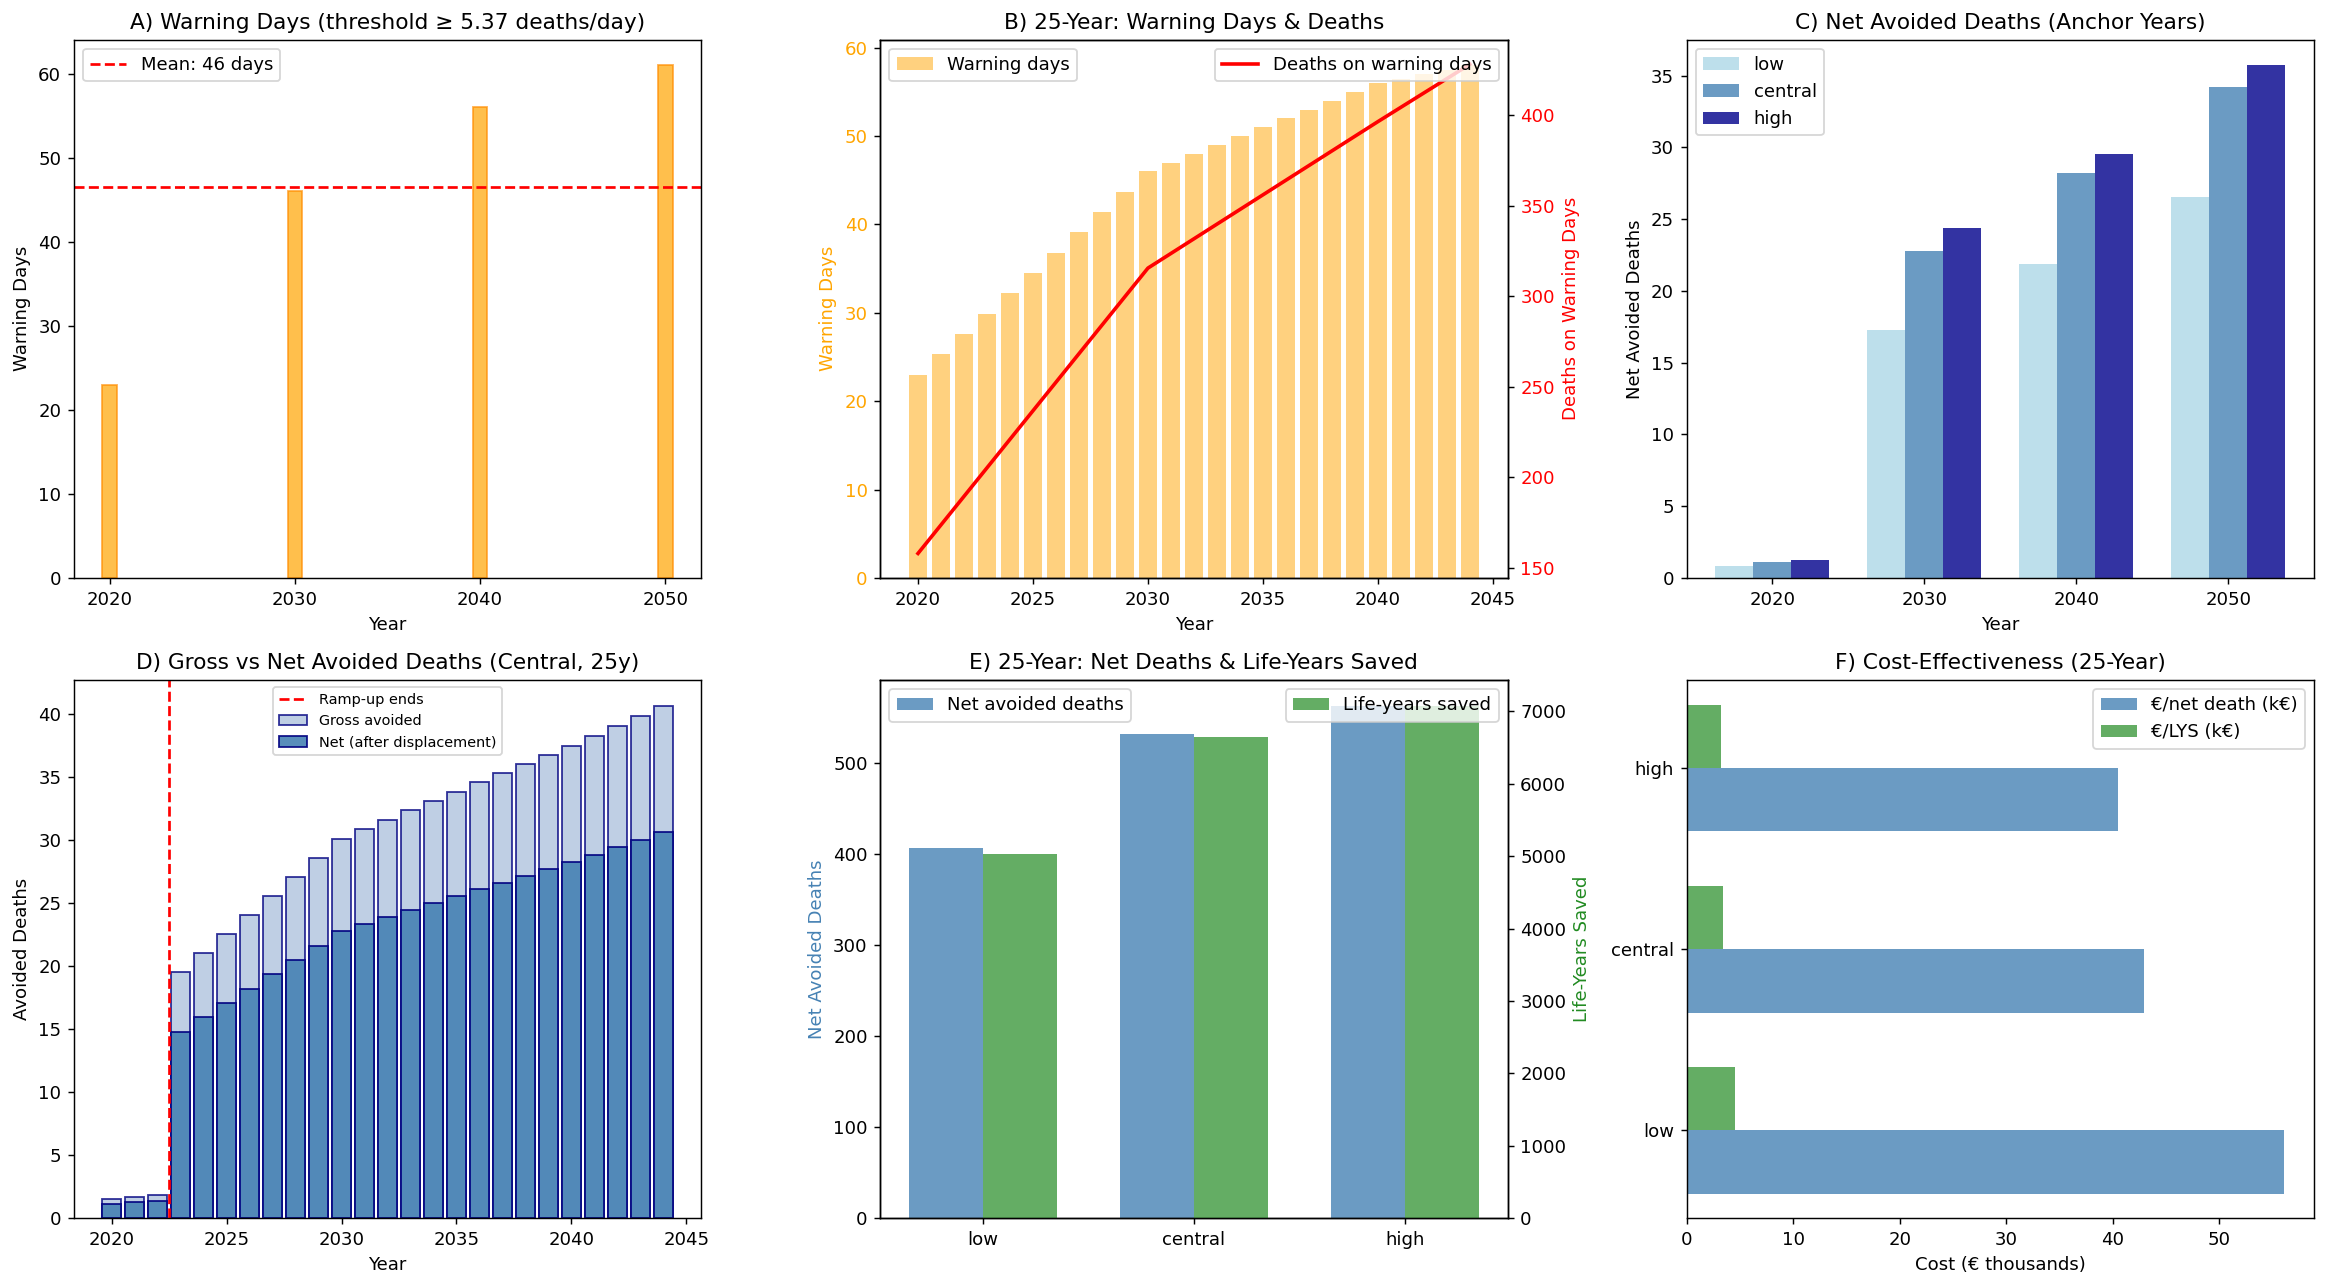

In [27]:
print("\n" + "=" * 70)
print("8. VISUALIZATION")
print("=" * 70)

scen_list = SCENARIO_NAMES if AGE_DIFFERENTIATED else list(EFFICACY_SCENARIOS.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel A: Warning days by year (anchor)
ax = axes[0, 0]
years_wd = warning_day_counts["year"]
days_wd = warning_day_counts["n_warning_days"]
ax.bar(years_wd, days_wd, color="orange", alpha=0.7, edgecolor="darkorange")
ax.axhline(y=days_wd.mean(), color="red", linestyle="--", label=f"Mean: {days_wd.mean():.0f} days")
ax.set_xlabel("Year")
ax.set_ylabel("Warning Days")
ax.set_title(f"A) Warning Days (threshold ≥ {thr_base:.2f} deaths/day)")
ax.legend()
ax.set_xticks(years_wd)

# Panel B: Warning days + deaths over 25 years
ax = axes[0, 1]
ax2 = ax.twinx()
ax.bar(YEARS_ALL, warning_days_25y, color="orange", alpha=0.5, label="Warning days")
ax.set_ylabel("Warning Days", color="orange")
ax.tick_params(axis='y', labelcolor="orange")
ax2.plot(YEARS_ALL, deaths_warning_25y, 'r-', linewidth=2, label="Deaths on warning days")
ax2.set_ylabel("Deaths on Warning Days", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax.set_xlabel("Year")
ax.set_title("B) 25-Year: Warning Days & Deaths")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

# Panel C: Net avoided deaths by scenario (anchor years)
ax = axes[0, 2]
width = 0.25
x = np.arange(len(YEARS_H))
colors_map = {"low": "lightblue", "central": "steelblue", "high": "darkblue"}
for i, scen in enumerate(scen_list):
    scen_data = ews_benefits_df[ews_benefits_df["scenario"] == scen]
    vals = scen_data["net_avoided_deaths"].values
    ax.bar(x + i*width, vals, width, label=f"{scen}", color=colors_map.get(scen, "gray"), alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Net Avoided Deaths")
ax.set_title("C) Net Avoided Deaths (Anchor Years)")
ax.set_xticks(x + width)
ax.set_xticklabels(YEARS_H)
ax.legend()

# Panel D: 25-year central: gross vs net avoided deaths
ax = axes[1, 0]
central_25y = EWS_25Y_DF[EWS_25Y_DF["scenario"] == "central"]
ax.bar(central_25y["year"], central_25y["gross_avoided_deaths"], color="lightsteelblue",
       alpha=0.8, edgecolor="navy", label="Gross avoided")
ax.bar(central_25y["year"], central_25y["net_avoided_deaths"], color="steelblue",
       alpha=0.9, edgecolor="navy", label="Net (after displacement)")
ramp_years = int(EWS_CONFIG["ramp_years"])
ax.axvline(x=2020 + ramp_years - 0.5, color="red", linestyle="--", label=f"Ramp-up ends")
ax.set_xlabel("Year")
ax.set_ylabel("Avoided Deaths")
ax.set_title("D) Gross vs Net Avoided Deaths (Central, 25y)")
ax.legend(fontsize=8)

# Panel E: Life-years saved by scenario (25y cumulative)
ax = axes[1, 1]
lys_vals = [EWS_25Y_SUMMARY[s]['life_years_saved_cum'] for s in scen_list]
net_vals = [EWS_25Y_SUMMARY[s]['net_avoided_deaths_cum'] for s in scen_list]

x = np.arange(len(scen_list))
width = 0.35
ax.bar(x - width/2, net_vals, width, label='Net avoided deaths', color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.bar(x + width/2, lys_vals, width, label='Life-years saved', color='forestgreen', alpha=0.7)
ax.set_ylabel("Net Avoided Deaths", color="steelblue")
ax2.set_ylabel("Life-Years Saved", color="forestgreen")
ax.set_title("E) 25-Year: Net Deaths & Life-Years Saved")
ax.set_xticks(x)
ax.set_xticklabels(scen_list)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

# Panel F: Cost-effectiveness (€/LYS and €/death)
ax = axes[1, 2]
eur_per_death = [EWS_25Y_SUMMARY[s]['cost_per_death_net_cum'] / 1e3 for s in scen_list]
eur_per_lys = [EWS_25Y_SUMMARY[s]['cost_per_lys_cum'] / 1e3 for s in scen_list]

x = np.arange(len(scen_list))
width = 0.35
bars1 = ax.barh(x - width/2, eur_per_death, width, label='€/net death (k€)', color='steelblue', alpha=0.8)
bars2 = ax.barh(x + width/2, eur_per_lys, width, label='€/LYS (k€)', color='forestgreen', alpha=0.7)
ax.set_xlabel("Cost (€ thousands)")
ax.set_title("F) Cost-Effectiveness (25-Year)")
ax.set_yticks(x)
ax.set_yticklabels(scen_list)
ax.legend()

plt.tight_layout()
fig_path = OUT / "figures" / f"{SLUG}_ews_summary_25y.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"  Saved: {fig_path}")
plt.show()

## 8. Save outputs

The notebook writes both anchor-year tables and compact 25-year summary products. These files provide the EWS inputs for `NB08`, and the parameter JSON preserves the resolved config choices for traceability.


In [28]:
print("\n" + "=" * 70)
print("8. SAVING OUTPUTS")
print("=" * 70)

tables_dir = OUT / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# 8.1 Warning-day summary
warning_output = warning_day_counts.copy()
warning_output["threshold_deaths_per_day"] = [threshold_by_year.get(y, thr_base) for y in warning_output["year"]]
warning_output["threshold_method"] = thr_meta["method"]
warning_output["season_start_md"] = SEASON_START_MD
warning_output["season_end_md"] = SEASON_END_MD
warning_output["season_source"] = WARNING_SEASON_META.get("source", "warning_months_fallback")
warning_output.to_csv(tables_dir / f"{SLUG}_ews_warning_days.csv", index=False)
print(f"  Saved: {SLUG}_ews_warning_days.csv")

# 8.2 Annual baseline deaths under current AC
baseline_output = annual_base[["year", "deaths_overall", "deaths_on_warning_days",
                               "frac_deaths_on_warning_days", "n_warning_days"]].copy()
baseline_output.to_csv(tables_dir / f"annual_heat_deaths_baseline_current_ac_{SLUG}.csv", index=False)
print(f"  Saved: annual_heat_deaths_baseline_current_ac_{SLUG}.csv")

# 8.3 Anchor-year EWS benefits, including age detail, displacement, and life-years saved
ews_benefits_df.to_csv(tables_dir / f"annual_heat_deaths_avoided_EWS_{SLUG}.csv", index=False)
print(f"  Saved: annual_heat_deaths_avoided_EWS_{SLUG}.csv")

# 8.4 Twenty-five-year EWS benefits, including age detail, displacement, and life-years saved
EWS_25Y_DF.to_csv(tables_dir / f"ews_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: ews_benefits_25y_{SLUG}.csv")

# 8.5 Twenty-five-year EWS time series
ews_timeseries_25y = pd.DataFrame({
    "year": YEARS_ALL,
    "warning_days": warning_days_25y,
    "deaths_on_warning_days": deaths_warning_25y,
    "ramp_factor": ramp_factor_25y,
    "cost_capex": cost_capex_25y,
    "cost_opex": cost_opex_25y,
    "cost_total": cost_total_25y,
    "cost_pv": cost_pv_25y,
    "discount_factor": discount_factors_25y,
})
ews_timeseries_25y.to_csv(tables_dir / f"ews_timeseries_25y_{SLUG}.csv", index=False)
print(f"  Saved: ews_timeseries_25y_{SLUG}.csv")

# 8.6 Anchor-year EWS costs
costs_df.to_csv(tables_dir / f"{SLUG}_ews_costs_annual.csv", index=False)
print(f"  Saved: {SLUG}_ews_costs_annual.csv")

# 8.7 Comprehensive parameter JSON for reproducibility
scen_list = SCENARIO_NAMES if AGE_DIFFERENTIATED else list(EFFICACY_SCENARIOS.keys() if not AGE_DIFFERENTIATED else [])
params = {
    "city": CITY,
    "slug": SLUG,
    "interpretation": EWS_CONFIG["interpretation"],
    "age_differentiated": AGE_DIFFERENTIATED,
    "cost_model": EWS_CONFIG.get("cost_model", "chiabai"),
    "threshold": {
        "value_baseline": thr_base,
        "recalib_interval": EWS_CONFIG.get("threshold_recalib_interval", 0),
        "by_year": {str(y): v for y, v in threshold_by_year.items()},
        **thr_meta,
    },
    "warning_months": EWS_CONFIG.get("warning_months", []),
    "warning_season": dict(EWS_CONFIG.get("warning_season", {})) if EWS_CONFIG.get("warning_season") else {},
    "warning_season_resolved": dict(WARNING_SEASON_META),
    "archetype": EWS_CONFIG.get("archetype", None),
    "operational_trigger_mode": EWS_CONFIG.get("operational_trigger_mode", EWS_CONFIG.get("threshold_method", None)),
    "alert_tiers": dict(EWS_CONFIG.get("alert_tiers", {})) if EWS_CONFIG.get("alert_tiers") else {},
    "targeting": dict(EWS_CONFIG.get("targeting", {})) if EWS_CONFIG.get("targeting") else {},
    "cost_components": dict(EWS_CONFIG.get("cost_components", {})) if EWS_CONFIG.get("cost_components") else {},
    "efficacy": (
        {a: dict(v) for a, v in EFFICACY_SCENARIOS_BY_AGE.items()}
        if AGE_DIFFERENTIATED
        else EFFICACY_SCENARIOS
    ),
    "displacement": {a: dict(v) for a, v in DISPLACEMENT_BY_AGE.items()} if DISPLACEMENT_BY_AGE else {},
    "ac_overlap_factor": dict(AC_OVERLAP) if AC_OVERLAP else {},
    "residual_life_years": dict(RESIDUAL_LIFE_YEARS),
    "ramp": {
        "years": EWS_CONFIG["ramp_years"],
        "initial_efficacy": EWS_CONFIG["ramp_initial_efficacy"],
    },
    "costs": {
        "cost_model": EWS_CONFIG.get("cost_model", "chiabai"),
        "pavanello": dict(EWS_CONFIG.get("pavanello", {})),
        "chiabai": dict(EWS_CONFIG.get("chiabai", {})),
        "capex_setup": EWS_CONFIG.get("capex_setup"),
        "opex_annual_fixed": EWS_CONFIG.get("opex_annual_fixed"),
        "pv_total_25y": float(PV_EWS_COST_25Y),
    },
    "discount_rate": DISCOUNT_RATE,
    "horizon_years": HORIZON_YEARS,
    "study_years": YEARS_H,
    "horizon_25y": {
        "years": YEARS_ALL.tolist(),
        "pv_cost_total": float(PV_EWS_COST_25Y),
        "summary_by_scenario": {
            scen: {k: float(v) for k, v in vals.items()}
            for scen, vals in EWS_25Y_SUMMARY.items()
        },
    },
}
with open(tables_dir / f"{SLUG}_ews_parameters.json", "w") as f:
    json.dump(params, f, indent=2)
print(f"  Saved: {SLUG}_ews_parameters.json")

print(f"\n  Total files saved: 7")


8. SAVING OUTPUTS
  Saved: rome_ews_warning_days.csv
  Saved: annual_heat_deaths_baseline_current_ac_rome.csv
  Saved: annual_heat_deaths_avoided_EWS_rome.csv
  Saved: ews_benefits_25y_rome.csv
  Saved: ews_timeseries_25y_rome.csv
  Saved: rome_ews_costs_annual.csv
  Saved: rome_ews_parameters.json

  Total files saved: 7


## 9. Final check

The closing cell prints a compact audit trail of the active interpretation, threshold, warning season, costs, and main 25-year results. It is useful as a final sanity check before moving forward in the pipeline.


In [29]:
print("\n" + "=" * 70)
print("SUMMARY: Early Warning System Policy Analysis (IMPROVED)")
print("=" * 70)

central = EWS_25Y_SUMMARY.get('central', list(EWS_25Y_SUMMARY.values())[0])
cost_model = EWS_CONFIG.get('cost_model', 'chiabai')

print(f"""
City: {CITY}
Interpretation: {EWS_CONFIG['interpretation'].upper()}
Cost model: {cost_model.upper()}
Age-differentiated efficacy: {AGE_DIFFERENTIATED}

Warning System:
  Baseline threshold: {thr_base:.4f} deaths/day
  Recalibration: every {EWS_CONFIG.get('threshold_recalib_interval', 'N/A')} years (pop-scaled)
  Warning days: {warning_day_counts['n_warning_days'].mean():.0f}/year average (anchor)
  Warning season: {SEASON_LABEL} ({WARNING_SEASON_META.get('source')})

Improvements over previous version:
  1. Dual cost model (Pavanello per-capita / Chiabai per-day)
  2. Age-differentiated marginal efficacy (<15, 15-64, 65+)
  3. Threshold recalibration (pop-scaled every 5y)
  4. AC-EWS interaction (overlap factor penalises efficacy as AC rises)
  5. Mortality displacement (harvesting adjustment by age)
  6. Life-years saved metric alongside deaths avoided
""")

print(f"  Cost-effectiveness (25-year horizon, {cost_model}):")
print(f"  {'Scenario':<10} {'Gross':>8} {'Net':>8} {'LYS':>8} {'€/net death':>14} {'€/LYS':>10}")
print(f"  {'-'*64}")
for scen, v in EWS_25Y_SUMMARY.items():
    print(f"  {scen:<10} {v['gross_avoided_deaths_cum']:>8.1f} {v['net_avoided_deaths_cum']:>8.1f} "
          f"{v['life_years_saved_cum']:>8.0f} €{v['cost_per_death_net_cum']:>13,.0f} €{v['cost_per_lys_cum']:>9,.0f}")

print(f"""
PV total cost (25y): €{PV_EWS_COST_25Y:,.0f}

Key Methodological Notes:
1. Baseline = deaths under current AC (from NB5)
2. Age-differentiated efficacy applied to warning-day deaths by age group
3. AC-EWS interaction: overlap factor reduces EWS efficacy as AC coverage rises
4. Displacement: age-specific fraction of avoided deaths are harvested (short-term displaced)
5. Net avoided deaths = gross × (1 - displacement)
6. LYS = net avoided deaths × residual life expectancy by age
7. Ramp-up: {EWS_CONFIG['ramp_years']} years at {EWS_CONFIG['ramp_initial_efficacy']*100:.0f}% efficacy, then full

Files for NB8 CBA:
  - ews_benefits_25y_{SLUG}.csv (age-disaggregated avoided deaths + LYS by scenario)
  - ews_timeseries_25y_{SLUG}.csv (costs and warning days by year)
  - {SLUG}_ews_parameters.json (all parameters including 25y summary)
""")

print("=" * 70)
print(f"Notebook 6 complete. Outputs saved to: {tables_dir}")
print("=" * 70)


SUMMARY: Early Warning System Policy Analysis (IMPROVED)

City: Rome
Interpretation: MARGINAL
Cost model: PAVANELLO
Age-differentiated efficacy: True

Warning System:
  Baseline threshold: 5.3723 deaths/day
  Recalibration: every 5 years (pop-scaled)
  Warning days: 46/year average (anchor)
  Warning season: 05-01 to 09-30 (warning_season)

Improvements over previous version:
  1. Dual cost model (Pavanello per-capita / Chiabai per-day)
  2. Age-differentiated marginal efficacy (<15, 15-64, 65+)
  3. Threshold recalibration (pop-scaled every 5y)
  4. AC-EWS interaction (overlap factor penalises efficacy as AC rises)
  5. Mortality displacement (harvesting adjustment by age)
  6. Life-years saved metric alongside deaths avoided

  Cost-effectiveness (25-year horizon, pavanello):
  Scenario      Gross      Net      LYS    €/net death      €/LYS
  ----------------------------------------------------------------
  low           451.1    406.5     5027 €       56,097 €    4,536
  central  